# TECH CHALLENGE FASE 1 - EDA

Entendimento do negócio

● **Qual problema de negócio está sendo resolvido?**

A reatividade operacional, ou seja, a empresa perde clientes e dinheiro porque só descobre a insatisfação quando o dano (churn) já é iminente ou irreversível.


● **Por que o NPS é importante para um e-commerce?**

O NPS é importante para medir a satisfação do cliente, fazer com que ele volte a comprar no e-commerce e ainda seja um promotor da empresa, ou seja, indicando aquele e-commerce para outras pessoas. Além disso, é financeiramente mais barato recuperar um "Neutro” do que um "Detrator que teve um produto entregue com atraso por exemplo

● **Quais áreas poderiam se beneficiar desses insights? **

Correlacionando as variáveis que temos nos nossos dados, podemos entender onde as falhas estão acontecendo.
Por exemplo:
Teve estoque? Se faltou, a área de compras não poderia ter uma previsibilidade melhor de demandas?
Teve atraso? A área de logística, não poderia ter melhor planejamento nas entregas?
Teve problemas e o atendimento foi demorado? Podemos tentar antecipar problemas e ter um contato proativo do time de atendimento.


**Passo 1:** Import do arquivo desafio_nps_fase_1.csv como tabela no BigQuery:
`vanehay.1IAST.desafio_nps_fase_1`
O import foi feito via Console e foi feito uma primeira analise nos dados usando SQL


In [1]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
SELECT
    -- Segmentação por Faixa de NPS (Promotores, Neutros, Detratores)
    CASE
        WHEN nps_score >= 9 THEN 'Promotor'
        WHEN nps_score >= 7 THEN 'Neutro'
        ELSE 'Detrator'
    END AS perfil_nps,

    -- Métricas de Fidelidade
    COUNT(customer_id) AS total_clientes,
    SUM(repeat_purchase_30d) AS total_recompras_30d,
    ROUND(AVG(repeat_purchase_30d) * 100, 2) AS taxa_recompra_percent,
    ROUND(AVG(customer_tenure_months), 1) AS tempo_medio_relacionamento_meses,

    -- Métricas de Operação
    ROUND(AVG(delivery_delay_days), 2) AS media_atraso_entrega,
    ROUND(AVG(customer_service_contacts), 2) AS media_contatos_suporte,
    SUM(complaints_count) AS total_reclamacoes

FROM `vanehay.1IAST.desafio_nps_fase_1`
GROUP BY 1
ORDER BY 1;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

,perfil_nps,total_clientes,total_recompras_30d,taxa_recompra_percent,tempo_medio_relacionamento_meses,media_atraso_entrega,media_contatos_suporte,total_reclamacoes
0,Detrator,2109,0,0.0,61.4,2.41,1.63,9369
1,Neutro,281,108,38.43,59.8,1.05,1.01,757
2,Promotor,110,110,100.0,63.0,0.72,0.67,250


In [2]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
--O que mais gera detratores? (Análise de Atrito)

SELECT
    CASE WHEN nps_score <= 6 THEN 'Detrator' ELSE 'Outros' END AS categoria,
    ROUND(AVG(customer_service_contacts), 2) AS media_contatos_suporte,
    ROUND(AVG(complaints_count), 2) AS media_reclamacoes,
    ROUND(AVG(delivery_delay_days), 2) AS media_dias_atraso_entrega
FROM `vanehay.1IAST.desafio_nps_fase_1`
GROUP BY 1;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

,categoria,media_contatos_suporte,media_reclamacoes,media_dias_atraso_entrega
0,Detrator,1.69,4.62,2.53
1,Outros,1.02,2.8,1.2


**Passo 2:** Import da tabela para um bigframe lib da google cloud para manipular dataframes e manter o processamento no bigquery, sem utilizar processamento local

In [3]:
#Libs que serão utilizadas no projeto
import pandas as pd
import numpy as np
import bigframes.pandas as bpd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [4]:
#Declaracao das variaveis
PROJECT_ID = "vanehay"
DATASET_ID = "1IAST"
TABLE_NAME = "desafio_nps_fase_1"
table_ref = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}"

In [5]:
# Carregamento de dados utilizando a biblioteca bigframe similar ao pandas
df_full_nps = bpd.read_gbq(table_ref)
df_full_nps.head()

print("Quantidade de linhas e colunas do dataframe:")
print(df_full_nps.shape)

Quantidade de linhas e colunas do dataframe:


(2500, 19)


In [6]:
print("Tipos de cada coluna")
print(df_full_nps.dtypes)

Tipos de cada coluna
customer_id                            Int64
customer_age                           Int64
customer_region              string[pyarrow]
customer_tenure_months                 Int64
order_id                               Int64
order_value                          Float64
items_quantity                         Int64
discount_value                       Float64
payment_installments                   Int64
delivery_time_days                     Int64
delivery_delay_days                    Int64
freight_value                        Float64
delivery_attempts                      Int64
customer_service_contacts              Int64
resolution_time_days                   Int64
nps_score                            Float64
repeat_purchase_30d                    Int64
complaints_count                       Int64
csat_internal_score                  Float64
dtype: object


In [7]:
print("Valores nulos")
df_full_nps.isnull().sum()

Valores nulos


customer_id               0
customer_age              0
customer_region           0
customer_tenure_months    0
order_id                  0
order_value               0
items_quantity            0
discount_value            0
payment_installments      0
delivery_time_days        0
Name: 0, dtype: Int64
...

[19 rows]

In [9]:
print("Colunas carregadas no dataframe")
df_full_nps.columns

Colunas carregadas no dataframe


Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

In [11]:
print("Resumo estatístico do dataframe")
df_full_nps.describe().round(2)

Resumo estatístico do dataframe


,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0
mean,1250.5,43.4,61.32,51250.5,434.26,3.47,29.75,6.0,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.0,18.0,1.0,50001.0,7.76,1.0,0.02,1.0,2.0,0.0,2.62,1.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,615.0,31.0,31.0,50615.0,220.47,2.0,8.62,3.0,5.0,1.0,29.6,1.0,1.0,2.0,2.5,0.0,3.0,0.7
50%,1251.0,43.0,62.0,51251.0,375.02,3.0,20.72,6.0,8.0,2.0,38.52,2.0,1.0,5.0,4.4,0.0,4.0,2.8
75%,1867.0,56.0,91.0,51867.0,575.72,5.0,40.24,9.0,11.0,3.0,46.24,3.0,2.0,8.0,6.1,0.0,5.0,4.8
max,2500.0,69.0,119.0,52500.0,1983.81,6.0,230.33,11.0,14.0,8.0,76.13,3.0,7.0,11.0,10.0,1.0,11.0,10.0


**Passo 3:** Criação das variáveis de negócio

O NPS (Net Promoter Score) é uma métrica de fidelidade e satisfação do cliente que avalia a probabilidade de recomendação de uma empresa, produto ou serviço, numa escala de 0 a 10. Ele classifica clientes em promotores (9-10), neutros (7-8) ou detratores (0-6), ajudando a identificar a saúde do negócio e oportunidades de melhoria.

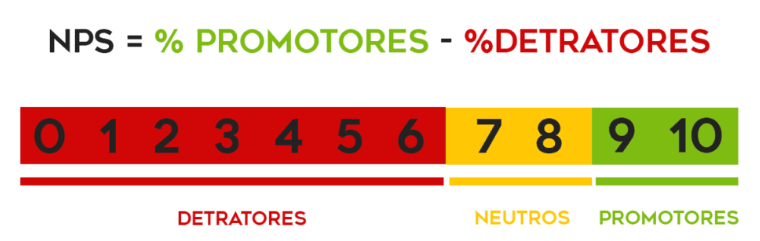




In [14]:
# A funçao categorizar_nps classifica cada cliente da base de acordo
#  com a métrica oficial.

def categorizar_nps(df):
    """Categoriza o NPS com base na coluna nps_score."""
    score = df['nps_score']

    perfil = bpd.Series("Detrator", index=df.index)

    return perfil.case_when([
        (score >= 9, "Promotor"),
        (score >= 7, "Neutro")
    ])


df_full_nps['profile_nps'] = categorizar_nps(df_full_nps)
print("5 primeiras linhas com a nova coluna: ")
df_full_nps.head()



5 primeiras linhas com a nova coluna: 


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,profile_nps
0,1132,29,Norte,110,51132,410.46,2,7.89,11,7,1,56.66,2,2,8,5.0,0,4,2.1,Detrator
1,639,40,Norte,62,50639,298.61,2,10.01,11,7,1,38.65,1,2,10,7.0,0,3,0.5,Neutro
2,2003,36,Sudeste,6,52003,164.11,2,18.91,6,8,1,30.45,1,1,11,7.5,0,2,1.4,Neutro
3,1401,68,Sudeste,65,51401,144.49,3,96.15,10,6,3,42.59,1,0,6,4.1,0,3,2.8,Detrator
4,367,18,Centro-Oeste,70,50367,45.74,3,3.66,10,2,2,44.48,1,2,10,3.1,0,4,0.0,Detrator


In [15]:
print("Distribuição da base de dados")
df_full_nps.profile_nps.value_counts()

Distribuição da base de dados


profile_nps
Detrator    2109
Neutro       281
Promotor     110
Name: count, dtype: Int64

**Passo 4:** Correlação das variaveis da base com o NPS

In [22]:
correlacoes = df_full_nps.corr(numeric_only=True)['nps_score']
correlacoes

customer_id               0.015162
customer_age             -0.009936
customer_tenure_months   -0.009711
order_id                  0.015162
order_value                0.03699
items_quantity            0.011468
discount_value            0.025104
payment_installments      0.023718
delivery_time_days        0.000925
delivery_delay_days       -0.59726
Name: nps_score, dtype: Float64
...

[18 rows]

In [28]:
strong_correlations = correlacoes[(correlacoes.abs() >= 0.5)].drop('nps_score')

In [31]:
# Filtrar correlações mais próximas de +1 ou -1 (excluindo a correlação da própria nps_score com ela mesma)
strong_correlations = correlacoes[(correlacoes.abs() >= 0.5)].drop('nps_score')
if not strong_correlations.empty:
    print("Correlações mais fortes com o NPS (próximas de +1 ou -1):\n")
    print(strong_correlations.sort_values(ascending=False))
else:
    print("Não foram encontradas correlações fortes com o NPS (abs >= 0.5).")


Correlações mais fortes com o NPS (próximas de +1 ou -1):



repeat_purchase_30d    0.570324
csat_internal_score    0.563952
delivery_delay_days    -0.59726
Name: nps_score, dtype: Float64


In [16]:
result = df_full_nps.groupby('profile_nps').agg(
    total_clientes=('customer_id', 'count'),
    total_recompras_30d=('repeat_purchase_30d', 'sum'),
    taxa_recompra_percent=('repeat_purchase_30d', 'mean'),
    tempo_medio_relacionamento_meses=('customer_tenure_months', 'mean'),
    media_atraso_entrega=('delivery_delay_days', 'mean'),
    media_contatos_suporte=('customer_service_contacts', 'mean'),
    total_reclamacoes=('complaints_count', 'sum')
)

result['taxa_recompra_percent'] = (result['taxa_recompra_percent'] * 100).round(2)
result['tempo_medio_relacionamento_meses'] = result['tempo_medio_relacionamento_meses'].round(1)
result['media_atraso_entrega'] = result['media_atraso_entrega'].round(2)
result['media_contatos_suporte'] = result['media_contatos_suporte'].round(2)

result

,total_clientes,total_recompras_30d,taxa_recompra_percent,tempo_medio_relacionamento_meses,media_atraso_entrega,media_contatos_suporte,total_reclamacoes
profile_nps,,,,,,,
Detrator,2109,0,0.0,61.4,2.41,1.63,9369
Neutro,281,108,38.43,59.8,1.05,1.01,757
Promotor,110,110,100.0,63.0,0.72,0.67,250


**Passo 5:** Visualização da distribuiçao do NPS

In [32]:
#Criacao de um novo dataframe pandas para visualizacao
result.to_pandas()
df_plot = result.reset_index()

/tmp/ipykernel_1025/875874986.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='profile_nps', y='media_atraso_entrega', palette=colors)


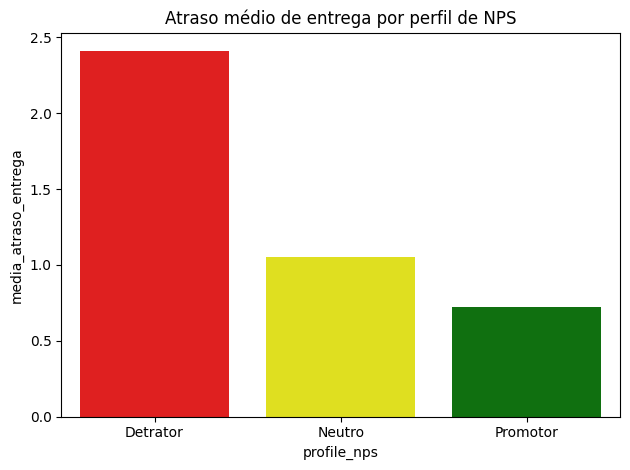

In [38]:
colors = {'Detrator': 'red', 'Neutro': 'yellow', 'Promotor': 'green'}
sns.barplot(data=df_plot, x='profile_nps', y='media_atraso_entrega', palette=colors)
plt.title('Atraso médio de entrega por perfil de NPS')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1025/3367047334.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='profile_nps', y='total_reclamacoes', palette=colors)


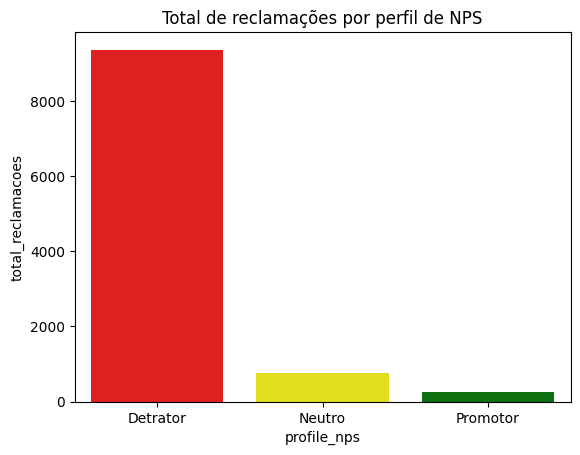

In [39]:
sns.barplot(data=df_plot, x='profile_nps', y='total_reclamacoes', palette=colors)
plt.title('Total de reclamações por perfil de NPS')
plt.show()